In [321]:
import numpy as np
import pandas as pd


### **Reading data**

In [453]:
test = pd.read_csv("/content/Test_dataset.csv")
train = pd.read_csv("/content/Train_dataset.csv")
test_raw = test.copy()

In [323]:
train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


### **Descriptive**

In [324]:
print("----------------------TRAIN INFO---------------------------")
print(f"shape of the dataset : {train.shape}")



----------------------TRAIN INFO---------------------------
shape of the dataset : (1966, 9)


In [325]:
print(f"shape of the dataset :{train.shape}")
print(f"NULL VALUES:\n{train.isnull().sum()}")
print("-----DATASET INFO------")
train.info()

shape of the dataset :(1966, 9)
NULL VALUES:
SEQN         12
RIAGENDR     18
PAQ605       13
BMXBMI       18
LBXGLU       13
DIQ010       18
LBXGLT       11
LBXIN         9
age_group    14
dtype: int64
-----DATASET INFO------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [326]:
train.columns

Index(['SEQN', 'RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT',
       'LBXIN', 'age_group'],
      dtype='object')

### **Renaming the columns**

In [327]:
train = train.rename(columns = {"RIAGENDR": "Sex", "PAQ605": "Phys_Activity", "BMXBMI":"BMI", "LBXGLU" : "Glucose_level",
                        "DIQ010" : "Diabetes_Ques", "LBXGLT": "Glucose_Tolerance_level", "LBXIN" : "Insulin_Level" })

In [328]:
train.head()

,SEQN,Sex,Phys_Activity,BMI,Glucose_level,Diabetes_Ques,Glucose_Tolerance_level,Insulin_Level,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [329]:
train.columns

Index(['SEQN', 'Sex', 'Phys_Activity', 'BMI', 'Glucose_level', 'Diabetes_Ques',
       'Glucose_Tolerance_level', 'Insulin_Level', 'age_group'],
      dtype='object')

In [330]:
train.shape

(1966, 9)

###**Data Visualization**

We can see that the distribution is right skewed, Mean > Median > Mode. Most of the values are towards the right side, that is most of the people have BMI between (20,35) and least number people have BMI > 45.

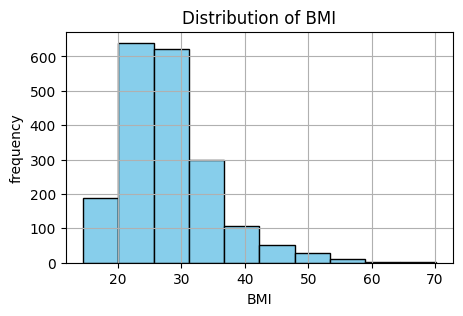

In [331]:
import matplotlib.pyplot as plt
plt.figure(figsize = (5,3))
plt.hist(train["BMI"], color = "skyblue", edgecolor = "black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("frequency")
plt.grid(True)
plt.show()

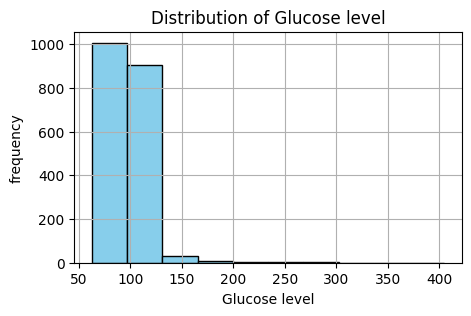

In [332]:
bins = [50,70,90,110,130,150,170]
plt.figure(figsize = (5,3))
plt.hist(train["Glucose_level"], color = "skyblue", edgecolor = "black")
plt.title("Distribution of Glucose level")
plt.xlabel("Glucose level")
plt.ylabel("frequency")
plt.grid(True)
plt.show()

### **Insulin Level**

/tmp/ipykernel_1871/3237525594.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  very_low = train.loc[train["Insulin_Level"] < 2].count()[0]
/tmp/ipykernel_1871/3237525594.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  low_normal = train.loc[(train["Insulin_Level"] > 2) & (train["Insulin_Level"] < 6)].count()[0]
/tmp/ipykernel_1871/3237525594.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normal = train.loc[(train["Insul

([<matplotlib.patches.Wedge at 0x7ee43364abd0>,
 [Text(1.4984795933607389, 0.06751968810232606, 'Very Low'),
  Text(0.6545516323097512, 0.8840600435720644, 'Low Normal'),
  Text(-1.097228148447887, 0.0780409524136004, 'Normal'),
  Text(0.4213919222032352, -1.01608505938325, 'High Normal'),
  Text(1.4644285215614783, -0.324729279919848, 'Elevated')],
 [Text(1.198783674688591, 0.054015750481860844, '1.43%'),
  Text(0.4760375507707282, 0.6429527589615014, '26.85%'),
  Text(-0.7979841079620996, 0.056757056300800295, '41.18%'),
  Text(0.3064668525114438, -0.7389709522787273, '23.59%'),
  Text(1.1715428172491826, -0.2597834239358784, '6.95%')])

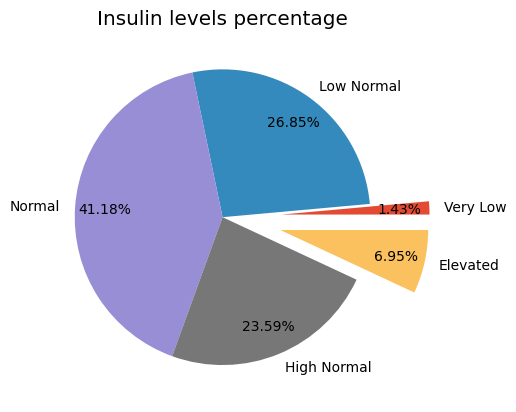

In [333]:
very_low = train.loc[train["Insulin_Level"] < 2].count()[0]
low_normal = train.loc[(train["Insulin_Level"] > 2) & (train["Insulin_Level"] < 6)].count()[0]
normal = train.loc[(train["Insulin_Level"] > 6) & (train["Insulin_Level"] < 12)].count()[0]
High_normal = train.loc[(train["Insulin_Level"] > 12) & (train["Insulin_Level"] < 20)].count()[0]
Elevated = train.loc[(train["Insulin_Level"] > 20) & (train["Insulin_Level"] < 28)].count()[0]

levels = [very_low, low_normal, normal, High_normal, Elevated]
labels = ["Very Low", "Low Normal", "Normal", "High Normal", "Elevated"]
explode = (0.4,0,0,0,0.4)
plt.style.use("ggplot")
plt.title("Insulin levels percentage")
plt.pie(levels, labels = labels, autopct = "%0.2f%%",explode = explode ,pctdistance = 0.8)

 **Now lets find out how these insulin levels are distributed amongst male and female**


In [334]:
def categ_insulin(row):
  if row < 2:
    return "very low"
  elif row > 2 and row < 6:
    return "low normal"
  elif row > 6 and row < 12:
    return "normal"
  elif row > 12 and row < 20:
    return "high normal"
  elif row > 20 and row < 28:
    return "elevated"
  else:
    return "very high"

train["categ_insulin"]  = train["Insulin_Level"].apply(categ_insulin)

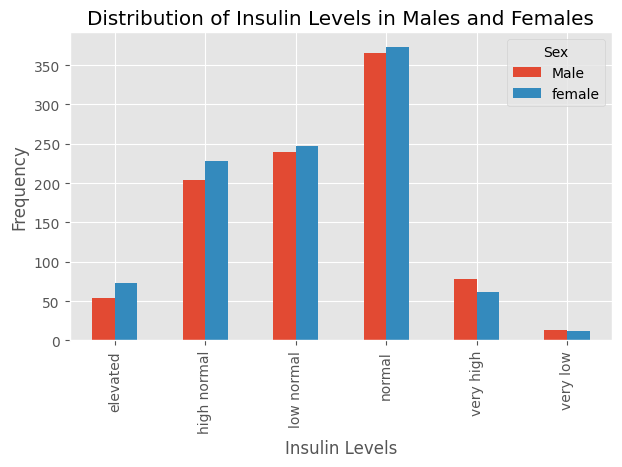

In [335]:
new = train.groupby("categ_insulin")["Sex"].value_counts().unstack()
sex_map = {1.0 : "Male", 2.0 : "female"}
new = new.rename(columns=sex_map)
new.plot(kind = "bar", figsize = (7,4))
plt.title("Distribution of Insulin Levels in Males and Females")
plt.xlabel("Insulin Levels")
plt.ylabel("Frequency")
plt.show()

### **Glucose Level**

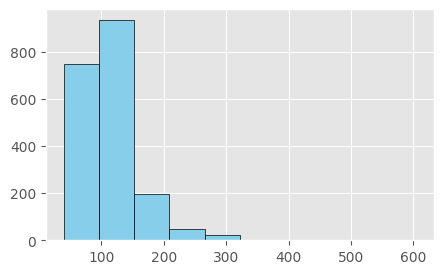

In [336]:
plt.figure(figsize = (5,3))
plt.hist(train["Glucose_Tolerance_level"], color = "skyblue", edgecolor = "black")
plt.show()

In [337]:
normal = train[train["Glucose_Tolerance_level"] < 140].count()[0]
Prediabetic = train[(train["Glucose_Tolerance_level"] > 140) & (train["Glucose_Tolerance_level"] < 200)].count()[0]
Diabetic = train[train["Glucose_Tolerance_level"] > 200].count()[0]

/tmp/ipykernel_1871/827209114.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normal = train[train["Glucose_Tolerance_level"] < 140].count()[0]
/tmp/ipykernel_1871/827209114.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Prediabetic = train[(train["Glucose_Tolerance_level"] > 140) & (train["Glucose_Tolerance_level"] < 200)].count()[0]
/tmp/ipykernel_1871/827209114.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Diabetic

([<matplotlib.patches.Wedge at 0x7ee433530fe0>,
 [Text(-0.9180871196420592, 0.6059010156348539, 'normal'),
  Text(0.9644806057992297, -0.8716519724277294, 'Prediabetic'),
  Text(1.2851018687046467, -0.19624776954611498, 'Diabetic')],
 [Text(-0.5007747925320323, 0.3304914630735566, '81.43%'),
  Text(0.5935265266456797, -0.5364012138016796, '13.74%'),
  Text(0.7908319192028594, -0.1207678581822246, '4.82%')])

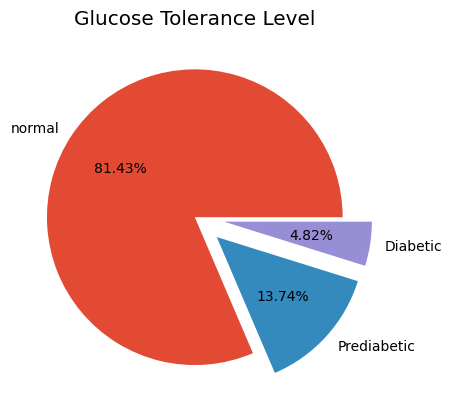

In [338]:
diab = [normal, Prediabetic, Diabetic]
label = ["normal", "Prediabetic", "Diabetic"]
plt.style.use("ggplot")
plt.title("Glucose Tolerance Level")
explode = (0,0.2,0.2)
plt.pie(diab, labels = label, autopct = "%0.2f%%", explode = explode)

In [339]:
def categ_glucose_level(row):
  if row < 140:
    return "normal"
  elif row > 140 and row < 200:
    return "Prediabetic"
  elif row > 200:
    return "Diabetic"

train["categ_glucose_level"] = train["Glucose_Tolerance_level"].apply(categ_glucose_level)

<Axes: xlabel='categ_glucose_level'>

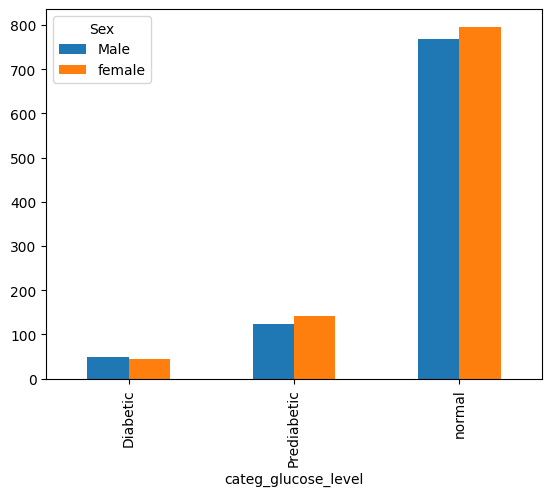

In [340]:
new2 = train.groupby("categ_glucose_level")["Sex"].value_counts().unstack()
sex_map = {1.0 : "Male", 2.0 : "female"}
new2 = new2.rename(columns = sex_map)
plt.style.use("default")
new2.plot(kind = "bar")

##### **Now lets find out how many of them are physically active**

In [341]:
train["Phys_Activity"].value_counts()

,count
Phys_Activity,
2.0,1606
1.0,346
7.0,1


<Axes: xlabel='categ_glucose_level'>

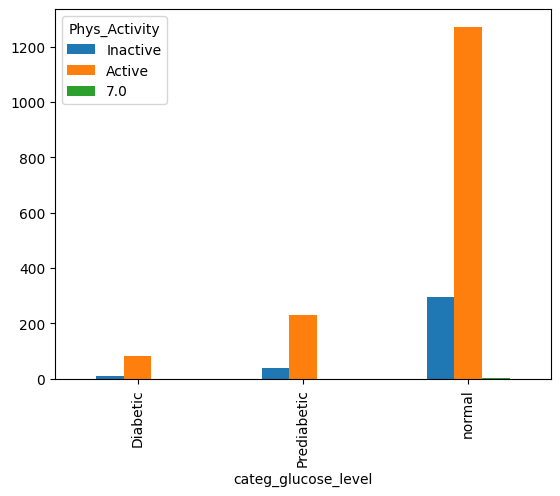

In [342]:
new3 = train.groupby("categ_glucose_level")["Phys_Activity"].value_counts().unstack()
map = {1.0 : "Inactive", 2.0 : "Active", 3.0 : "Missing"}
new3 = new3.rename(columns = map)
new3.plot(kind = "bar")

##### **Finding out the disease in different age groups**

We can see from the graph that diabetes in common in adults


<Figure size 500x300 with 0 Axes>

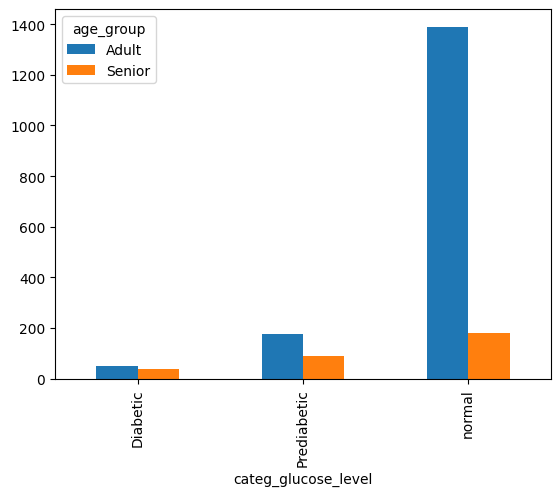

In [343]:
new4 = train.groupby("categ_glucose_level")["age_group"].value_counts().unstack()
plt.figure(figsize = (5,3))
new4.plot(kind = "bar")
plt.show()

### **Heat Map**

In [344]:
correl = train.select_dtypes(["number"]).corr()

<Axes: >

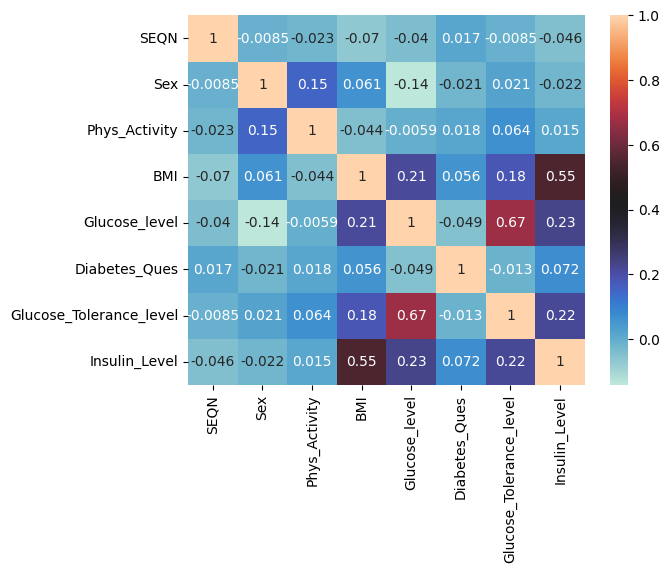

In [345]:
import seaborn as sns
sns.heatmap(correl, annot = True, cmap = "icefire")

1. Insulin Levels and BMI are positively correlated
2. Glucose Levels and BMI are positively correlated
3. BMI and physical Activity are negatively correlated

### **Target Column Analysis**

In [346]:
train.head()

,SEQN,Sex,Phys_Activity,BMI,Glucose_level,Diabetes_Ques,Glucose_Tolerance_level,Insulin_Level,age_group,categ_insulin,categ_glucose_level
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult,high normal,Prediabetic
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult,low normal,normal
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult,normal,normal
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult,high normal,normal
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult,normal,normal


### **Class Distribution**

Shows that the data is highly imbalanced

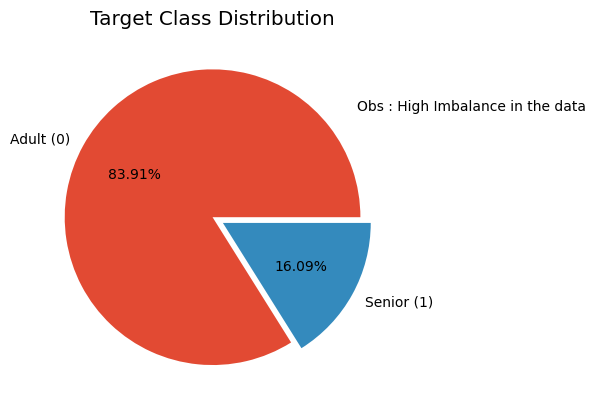

In [347]:
p = train["age_group"].value_counts()
label = ["Adult (0)", "Senior (1)"]
plt.style.use("ggplot")
explode = (0,0.08)
plt.pie(p, autopct = "%0.2f%%", labels = label, explode = explode)
# Added x and y coordinates for plt.text()
plt.text(1.2, 0.8, r"Obs : High Imbalance in the data", ha='center', va='center', transform=plt.gca().transAxes)
plt.title("Target Class Distribution")
plt.show()

#### **Distribution of target wrt each numeric column**

In [348]:
train["age_group"].value_counts()

,count
age_group,
Adult,1638
Senior,314


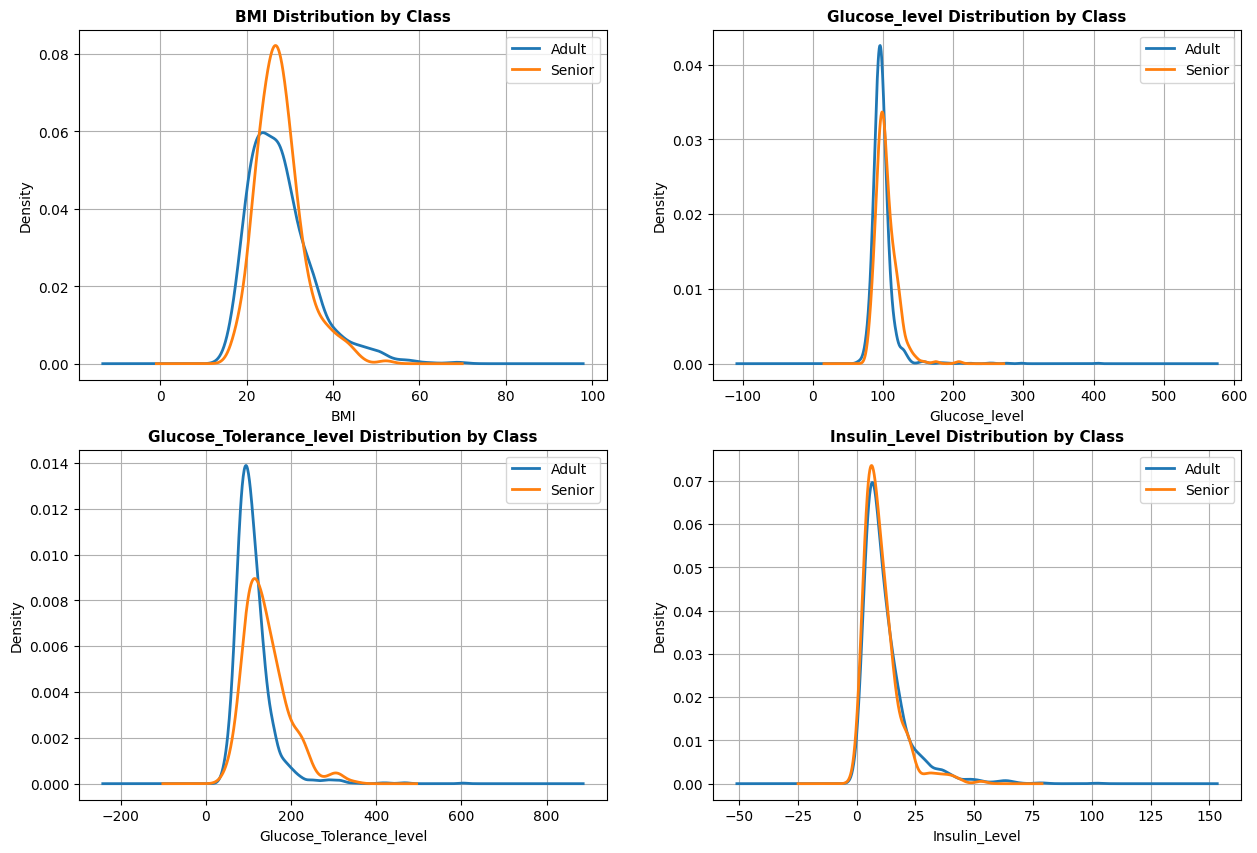

In [349]:
## Accessing all the numeric columns
plt.style.use("default")
df_numeric = train.select_dtypes(["number"])
numeric_column_names = df_numeric.columns.tolist()
df = [numeric_column_names[i] for i in [3, 4, 6, 7]]
fig, axes = plt.subplots(2,2, figsize = (15,10))
for ax, col in zip(axes.flat, df):
  for label, grp in train.groupby('age_group'):
        grp[col].dropna().plot.kde(ax=ax, label=label, linewidth=2)
  ax.set_title(f'{col} Distribution by Class', fontsize=11, fontweight='bold')
  ax.legend()
  ax.grid(True)
  ax.set_xlabel(col)

Shows the how probable each value is to occur, if density is high for certain interval => that those values are most frequent in the data in that particular age group

### **Categorical Feature distribution wrt age group**

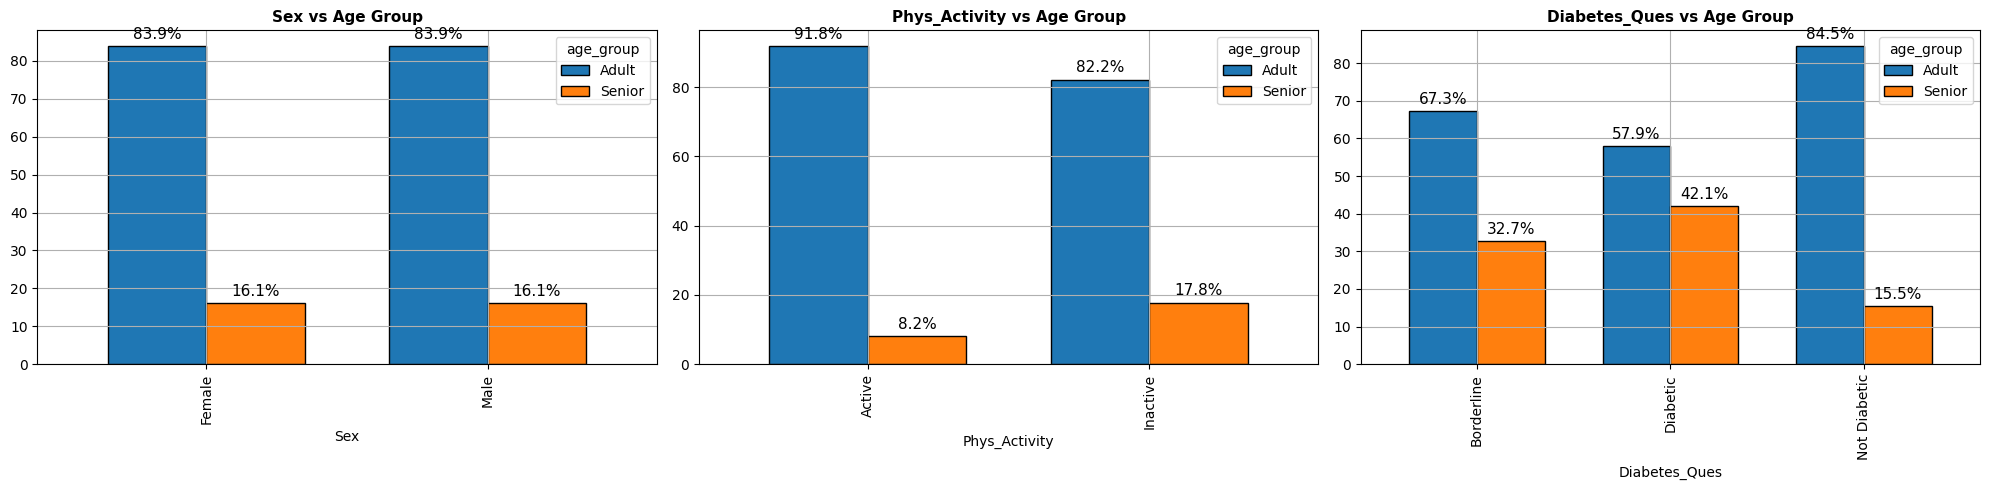

In [350]:
cols = ["Sex", "Phys_Activity", "Diabetes_Ques"]

plot_df = train.copy()
plot_df["Sex"] = plot_df["Sex"].map({1.0: 'Male', 2.0: 'Female'})
plot_df["Phys_Activity"] = plot_df["Phys_Activity"].map({1.0: 'Active', 2.0: 'Inactive'})
plot_df["Diabetes_Ques"] = plot_df["Diabetes_Ques"].map({1.0: 'Diabetic', 2.0: 'Not Diabetic', 3.0: 'Borderline', 9.0: "Don't know"})

fig, axes = plt.subplots(1,3 , figsize = (20,5))

for ax, col in zip(axes, cols):
  ct = pd.crosstab(plot_df[col], plot_df["age_group"], normalize = "index")*100
  ct.plot(kind = "bar", ax=ax, edgecolor = "black", width = 0.7)
  ax.set_title(f'{col} vs Age Group', fontsize=11, fontweight='bold')
  ax.grid(True)
  for p in ax.patches:
        if p.get_height() > 0: # Only label bars higher than 0%
            ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()


#### **Glucose and Insulin distributions by age group**

In [351]:
train.columns

Index(['SEQN', 'Sex', 'Phys_Activity', 'BMI', 'Glucose_level', 'Diabetes_Ques',
       'Glucose_Tolerance_level', 'Insulin_Level', 'age_group',
       'categ_insulin', 'categ_glucose_level'],
      dtype='object')

In [352]:
glu_sen = train[train["age_group"] == "Senior"]["Glucose_level"].dropna()
glu_adult = train[train["age_group"] == "Adult"]["Glucose_level"].dropna()
ins_adult = train[train["age_group"] == "Adult"]["Insulin_Level"].dropna()
ins_sen = train[train["age_group"] == "Senior"]["Insulin_Level"].dropna()

/tmp/ipykernel_1871/2171252715.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([glu_adult, glu_sen], labels = ["Adult", "Senior"])
/tmp/ipykernel_1871/2171252715.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ins_adult, ins_sen], labels = ["Adult", "Senior"])


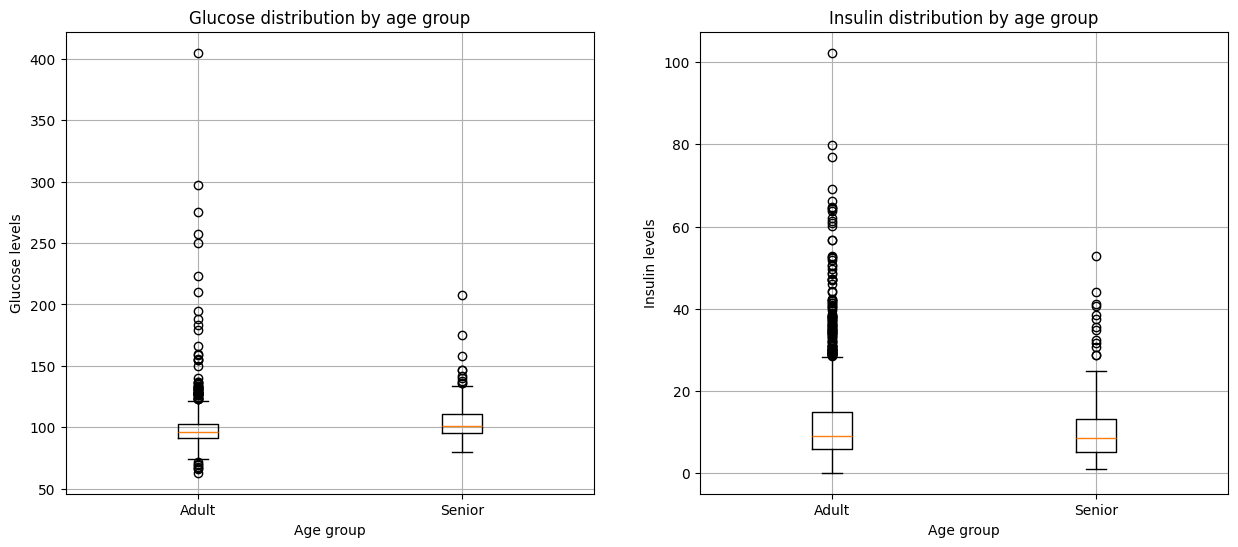

In [353]:
plt.figure(figsize = (15, 6))
plt.subplot(121)
plt.boxplot([glu_adult, glu_sen], labels = ["Adult", "Senior"])
plt.title("Glucose distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Glucose levels")
plt.grid(True)

plt.subplot(122)
plt.boxplot([ins_adult, ins_sen], labels = ["Adult", "Senior"])
plt.title("Insulin distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Insulin levels")
plt.grid(True)

plt.show()

1. There are a lot of Outliers in the data
2. Median of Glucose dist = 100, same approx for both the age groups    
3. Both the age groups in glucose dist spans a tight range between 90- 150.
4. There are extreme outliers observed in Adults.
5. Median of Insulin dist is around 10 for both the age groups
5. Range is 10 - 15 for both


**The Outlier Insight:** The adult group features extreme concurrent outliers in both graphs—glucose levels over 250–400 mg/dL paired with insulin spikes over 60–100 uIU/mL.

**Clinical Meaning:** This pattern is a classic presentation of severe insulin resistance. The pancreas is working chronically overtime (producing massive amounts of insulin) to overcome cellular resistance, yet it is still failing to bring blood glucose out of dangerous, uncontrolled hyperglycemic ranges. This signifies high prevalence or poor management of advanced Type 2 Diabetes within that specific adult cohort.

In [354]:
train.describe()

,SEQN,Sex,Phys_Activity,BMI,Glucose_level,Diabetes_Ques,Glucose_Tolerance_level,Insulin_Level
count,1954.000000,1948.000000,1953.000000,1948.000000,1953.000000,1948.000000,1955.000000,1957.000000
mean,78683.621801,1.510267,1.825397,27.965400,99.491039,2.015914,115.150384,11.862892
std,2924.115709,0.500023,0.399449,7.327616,16.774665,0.187579,46.271615,9.756713
min,73564.000000,1.000000,1.000000,14.500000,63.000000,1.000000,40.000000,0.140000
25%,76194.000000,1.000000,2.000000,22.800000,91.000000,2.000000,87.000000,5.800000
50%,78717.000000,2.000000,2.000000,26.800000,97.000000,2.000000,105.000000,9.030000
75%,81217.000000,2.000000,2.000000,31.300000,104.000000,2.000000,131.000000,14.480000
max,83727.000000,2.000000,7.000000,70.100000,405.000000,3.000000,604.000000,102.290000


### **Skewness**

1. Skewness close to 0 => symmetric
2. skewness < -1 or skewness > 1 is high

In [355]:
print(f"Skewness of column 'insulin level' : {train["Insulin_Level"].skew()}")
print(f"Skewness of column 'Glucose tolerance level' : {train["Glucose_Tolerance_level"].skew()}")
print(f"Skewness of column 'BMI' : {train["BMI"].skew()}")
print(f"Skewness of column 'Glucose level' : {train["Glucose_level"].skew()}")

Skewness of column 'insulin level' : 2.7065474834324057
Skewness of column 'Glucose tolerance level' : 2.6966251058252104
Skewness of column 'BMI' : 1.3552537905410076
Skewness of column 'Glucose level' : 6.479066999861089


We can obseve that column all the columns are positively skewed. None of these features can be considered approximately normal.To be considered approximately normal, a feature's skewness must fall within the strict threshold of -0.5 to +0.5.

/tmp/ipykernel_1871/1699307483.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Glucose_level"], kde = True, bins = 30)
/tmp/ipykernel_1871/1699307483.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Glucose_Tolerance_level"], kde = True, bins = 30)
/tmp/ipykernel_1871/16993

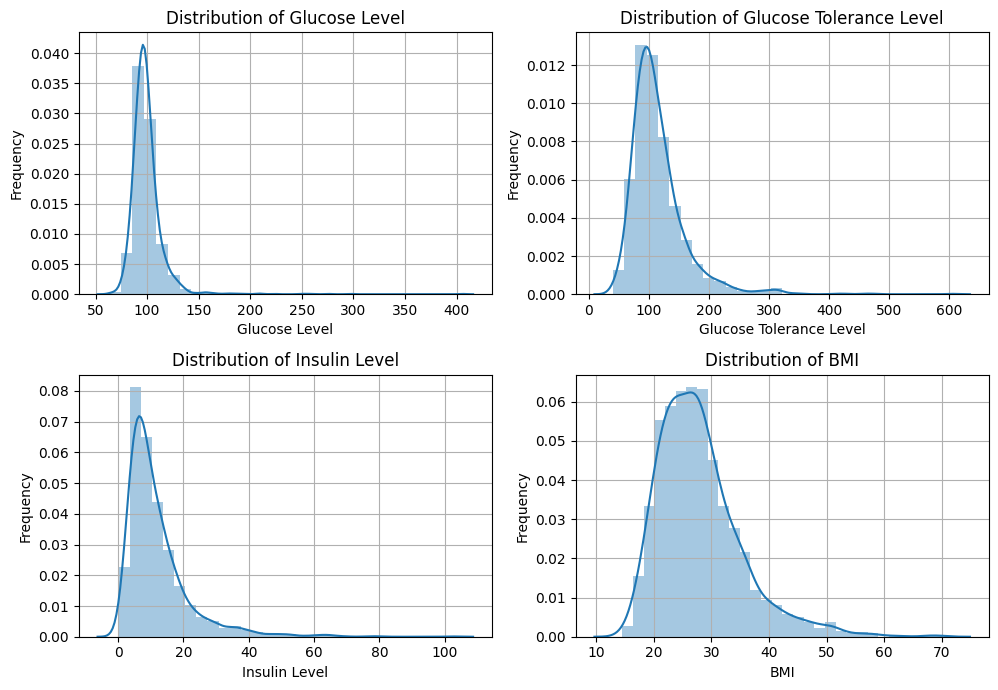

In [356]:
plt.figure(figsize = (10,7))

plt.subplot(221)
plt.style.use("default")
sns.distplot(train["Glucose_level"], kde = True, bins = 30)
plt.title('Distribution of Glucose Level')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(222)
plt.style.use("default")
sns.distplot(train["Glucose_Tolerance_level"], kde = True, bins = 30)
plt.title('Distribution of Glucose Tolerance Level')
plt.xlabel('Glucose Tolerance Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(223)
plt.style.use("default")
sns.distplot(train["Insulin_Level"], kde = True, bins = 30)
plt.title('Distribution of Insulin Level')
plt.xlabel('Insulin Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(224)
plt.style.use("default")
sns.distplot(train["BMI"], kde = True, bins = 30)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()

plt.show()

### **Outlier Treatment**

Methods are:
1. Z score : for normal
2. IQR method : for skewed
3. Percentile method

In [357]:
# We either capp the data or trim it. Trim when a point that is impossible is there and the frequency is also low.

In [358]:
new_df = train.copy()

In [426]:
IQR_glu = new_df["Glucose_level"].quantile(0.75) - new_df["Glucose_level"].quantile(0.25)
min_glu = new_df["Glucose_level"].quantile(0.25) - (IQR_glu * 1.5)
max_glu = new_df["Glucose_level"].quantile(0.75) + (IQR_glu * 1.5)

In [427]:
new_df["Glucose_level"] = np.where(new_df["Glucose_level"]<min_glu, min_glu, np.where(new_df["Glucose_level"]>max_glu, max_glu, new_df["Glucose_level"]))

In [361]:
print("----------Before treatment----------")
print(train["Glucose_level"].describe())
print(  "------------------------------------")
print("----------After treatment----------")
print(new_df["Glucose_level"].describe())

----------Before treatment----------
count    1953.000000
mean       99.491039
std        16.774665
min        63.000000
25%        91.000000
50%        97.000000
75%       104.000000
max       405.000000
Name: Glucose_level, dtype: float64
------------------------------------
----------After treatment----------
count    1953.000000
mean       98.385561
std        10.500736
min        71.500000
25%        91.000000
50%        97.000000
75%       104.000000
max       123.500000
Name: Glucose_level, dtype: float64


In [428]:
IQR_glu_tol = new_df["Glucose_Tolerance_level"].quantile(0.75) - new_df["Glucose_Tolerance_level"].quantile(0.25)
min_glu_tol = new_df["Glucose_Tolerance_level"].quantile(0.25) - (IQR_glu_tol * 1.5)
max_glu_tol = new_df["Glucose_Tolerance_level"].quantile(0.75) + (IQR_glu_tol * 1.5)

In [429]:
new_df["Glucose_Tolerance_level"] = np.where(new_df["Glucose_Tolerance_level"]<min_glu_tol, min_glu_tol, np.where(new_df["Glucose_Tolerance_level"] > max_glu_tol, max_glu_tol, new_df["Glucose_Tolerance_level"]))

In [364]:
print("----------Before treatment----------")
print(train["Glucose_Tolerance_level"].describe())
print(  "------------------------------------")
print("----------After treatment----------")
print(new_df["Glucose_Tolerance_level"].describe())

----------Before treatment----------
count    1955.000000
mean      115.150384
std        46.271615
min        40.000000
25%        87.000000
50%       105.000000
75%       131.000000
max       604.000000
Name: Glucose_Tolerance_level, dtype: float64
------------------------------------
----------After treatment----------
count    1955.000000
mean      112.173402
std        35.287184
min        40.000000
25%        87.000000
50%       105.000000
75%       131.000000
max       197.000000
Name: Glucose_Tolerance_level, dtype: float64


In [430]:
IQR_ins = new_df["Insulin_Level"].quantile(0.75) - new_df["Insulin_Level"].quantile(0.25)
min_ins = new_df["Insulin_Level"].quantile(0.25) - (IQR_ins * 1.5)
max_ins = new_df["Insulin_Level"].quantile(0.75) + (IQR_ins * 1.5)

In [431]:
new_df["Insulin_Level"] = np.where(new_df["Insulin_Level"]<min_ins, min_ins, np.where(new_df["Insulin_Level"] > max_ins, max_ins, new_df["Insulin_Level"]))

In [367]:
print("----------Before treatment----------")
print(train["Insulin_Level"].describe())
print(  "------------------------------------")
print("----------After treatment----------")
print(new_df["Insulin_Level"].describe())

----------Before treatment----------
count    1957.000000
mean       11.862892
std         9.756713
min         0.140000
25%         5.800000
50%         9.030000
75%        14.480000
max       102.290000
Name: Insulin_Level, dtype: float64
------------------------------------
----------After treatment----------
count    1957.000000
mean       11.051426
std         6.993624
min         0.140000
25%         5.800000
50%         9.030000
75%        14.480000
max        27.500000
Name: Insulin_Level, dtype: float64


In [432]:
IQR_bmi = new_df["BMI"].quantile(0.75) - new_df["BMI"].quantile(0.25)
min_bmi = new_df["BMI"].quantile(0.25) - (IQR_bmi * 1.5)
max_bmi = new_df["BMI"].quantile(0.75) + (IQR_bmi * 1.5)

In [433]:
new_df["BMI"] = np.where(new_df["BMI"]<min_bmi, min_bmi, np.where(new_df["BMI"] > max_bmi, max_bmi, new_df["BMI"]))

In [370]:
print("----------Before treatment----------")
print(train["BMI"].describe())
print(  "------------------------------------")
print("----------After treatment----------")
print(new_df["BMI"].describe())

----------Before treatment----------
count    1948.000000
mean       27.965400
std         7.327616
min        14.500000
25%        22.800000
50%        26.800000
75%        31.300000
max        70.100000
Name: BMI, dtype: float64
------------------------------------
----------After treatment----------
count    1948.000000
mean       27.726463
std         6.575248
min        14.500000
25%        22.800000
50%        26.800000
75%        31.300000
max        44.050000
Name: BMI, dtype: float64


In [371]:
glu_sen = new_df[new_df["age_group"] == "Senior"]["Glucose_level"].dropna()
glu_adult = new_df[new_df["age_group"] == "Adult"]["Glucose_level"].dropna()
ins_adult = new_df[new_df["age_group"] == "Adult"]["Insulin_Level"].dropna()
ins_sen = new_df[new_df["age_group"] == "Senior"]["Insulin_Level"].dropna()
glu_tol_sen = new_df[new_df["age_group"] == "Senior"]["Glucose_Tolerance_level"].dropna()
glu_tol_adult = new_df[new_df["age_group"] == "Adult"]["Glucose_Tolerance_level"].dropna()
bmi_sen = new_df[new_df["age_group"] == "Senior"]["BMI"].dropna()
bmi_adult = new_df[new_df["age_group"] == "Adult"]["BMI"].dropna()

/tmp/ipykernel_1871/3260314503.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([glu_adult, glu_sen], labels = ["Adult", "Senior"])
/tmp/ipykernel_1871/3260314503.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ins_adult, ins_sen], labels = ["Adult", "Senior"])
/tmp/ipykernel_1871/3260314503.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([glu_tol_sen, glu_tol_adult], labels = ["Adult","Senior"])
/tmp/ipykernel_1871/3260314503.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the ol

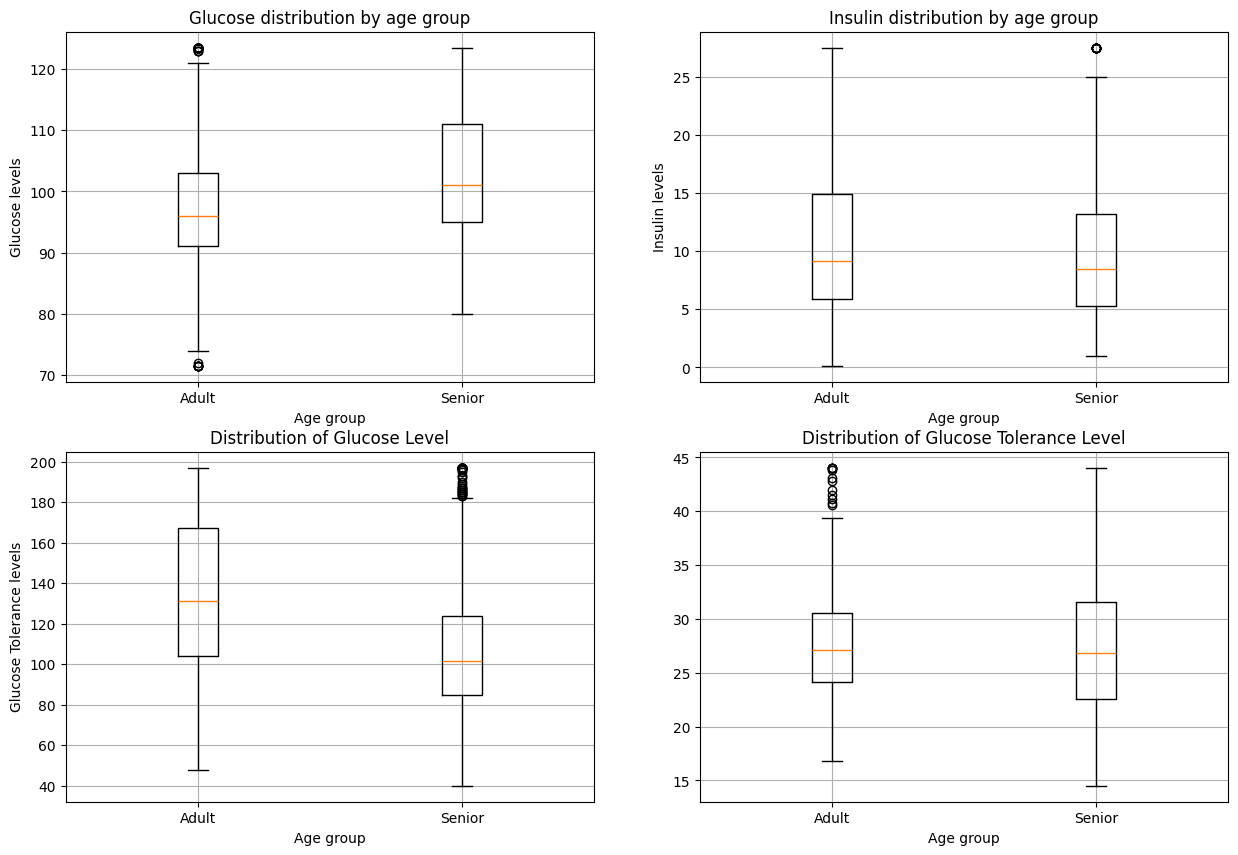

In [372]:
plt.figure(figsize = (15, 10))
plt.subplot(221)
plt.boxplot([glu_adult, glu_sen], labels = ["Adult", "Senior"])
plt.title("Glucose distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Glucose levels")
plt.grid(True)

plt.subplot(222)
plt.boxplot([ins_adult, ins_sen], labels = ["Adult", "Senior"])
plt.title("Insulin distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Insulin levels")
plt.grid(True)

plt.subplot(223)
plt.style.use("default")
plt.boxplot([glu_tol_sen, glu_tol_adult], labels = ["Adult","Senior"])
plt.title('Distribution of Glucose Level')
plt.grid(True)
plt.xlabel('Age group')
plt.ylabel('Glucose Tolerance levels')

plt.subplot(224)
plt.style.use("default")
plt.boxplot([bmi_sen, bmi_adult], labels = ["Adult","Senior"])
plt.title('Distribution of Glucose Tolerance Level')
plt.grid(True)
plt.xlabel('Age group')

plt.show()

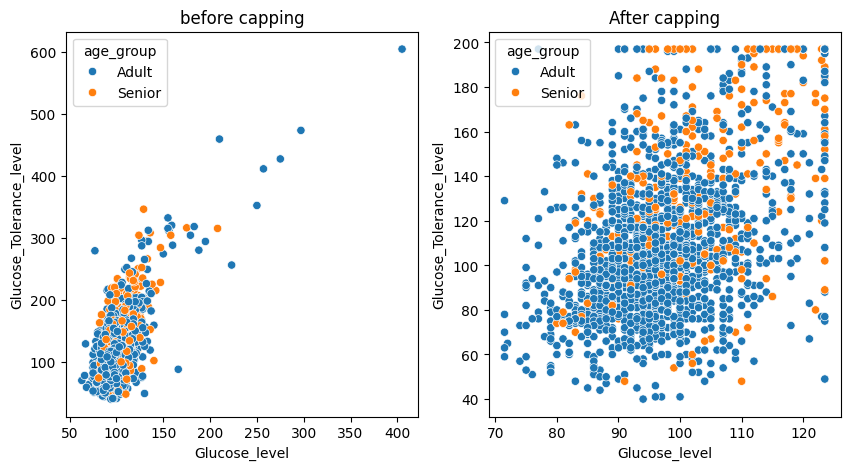

In [373]:
plt.figure(figsize = (10,5))
plt.subplot(121)
sns.scatterplot(x=train["Glucose_level"], y=train["Glucose_Tolerance_level"], hue = train["age_group"])
plt.title("before capping")

plt.subplot(122)
sns.scatterplot(x=new_df["Glucose_level"], y=new_df["Glucose_Tolerance_level"], hue = new_df["age_group"])
plt.title("After capping")
plt.show()

/tmp/ipykernel_1871/3621618963.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["Glucose_level"], kde = True, bins = 30)
/tmp/ipykernel_1871/3621618963.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["Glucose_Tolerance_level"], kde = True, bins = 30)
/tmp/ipykernel_1871/362

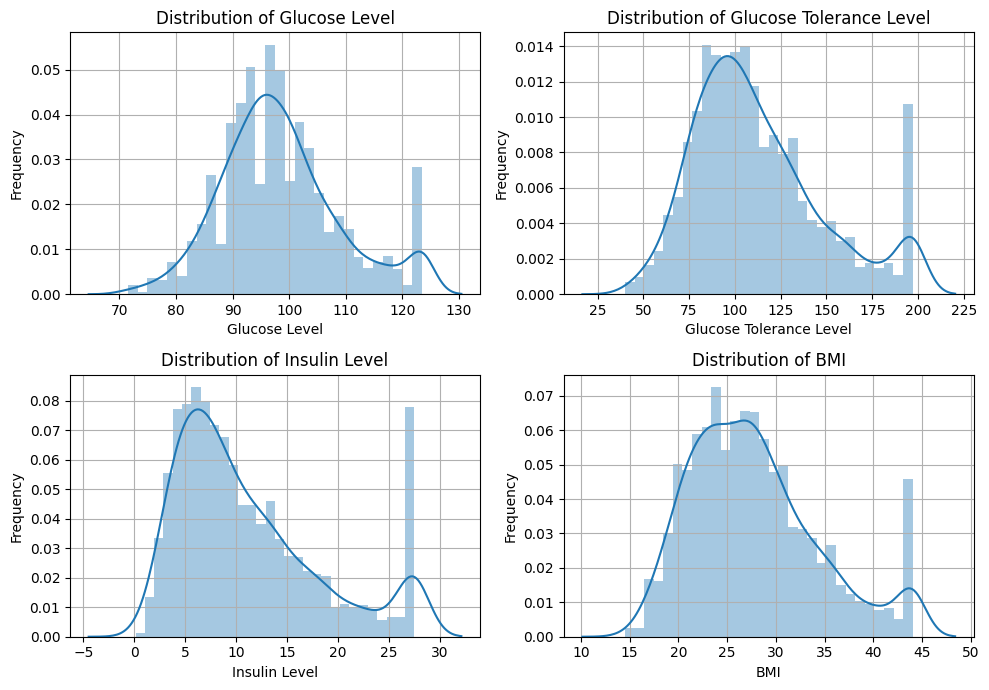

In [374]:
plt.figure(figsize = (10,7))

plt.subplot(221)
plt.style.use("default")
sns.distplot(new_df["Glucose_level"], kde = True, bins = 30)
plt.title('Distribution of Glucose Level')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(222)
plt.style.use("default")
sns.distplot(new_df["Glucose_Tolerance_level"], kde = True, bins = 30)
plt.title('Distribution of Glucose Tolerance Level')
plt.xlabel('Glucose Tolerance Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(223)
plt.style.use("default")
sns.distplot(new_df["Insulin_Level"], kde = True, bins = 30)
plt.title('Distribution of Insulin Level')
plt.xlabel('Insulin Level')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(224)
plt.style.use("default")
sns.distplot(new_df["BMI"], kde = True, bins = 30)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()

plt.show()

We can obseve that skewness is decreasing and tending to zero.

### **Handling missing values**

In [375]:
train.isnull().mean()*100

,0
SEQN,0.610376
Sex,0.915565
Phys_Activity,0.661241
BMI,0.915565
Glucose_level,0.661241
Diabetes_Ques,0.915565
Glucose_Tolerance_level,0.559512
Insulin_Level,0.457782
age_group,0.712106
categ_insulin,0.000000


In [376]:
new_df = new_df.drop(columns = "SEQN")

#### **Imputing categorical values**

In [377]:
new_df["Sex_mode"] = new_df["Sex"].fillna(new_df["Sex"].mode()[0])
new_df["Phys_activity_mode"] = new_df["Phys_Activity"].fillna(new_df["Phys_Activity"].mode()[0])
new_df["Diabetes_Ques_mode"] = new_df["Diabetes_Ques"].fillna(new_df["Diabetes_Ques"].mode()[0])

#### **Imputing numerical values**

In [378]:
new_df["BMI_mean"] = new_df["BMI"].fillna(new_df["BMI"].mean())
new_df["Glucose_level_mean"] = new_df["Glucose_level"].fillna(new_df["Glucose_level"].mean())
new_df["Glu_tol_mean"] = new_df["Glucose_Tolerance_level"].fillna(new_df["Glucose_Tolerance_level"].mean())
new_df["Ins_mean"] = new_df["Insulin_Level"].fillna(new_df["Insulin_Level"].mean())

##### **Checking if there are any outliers induced and if the shape of the distribution intact or not**

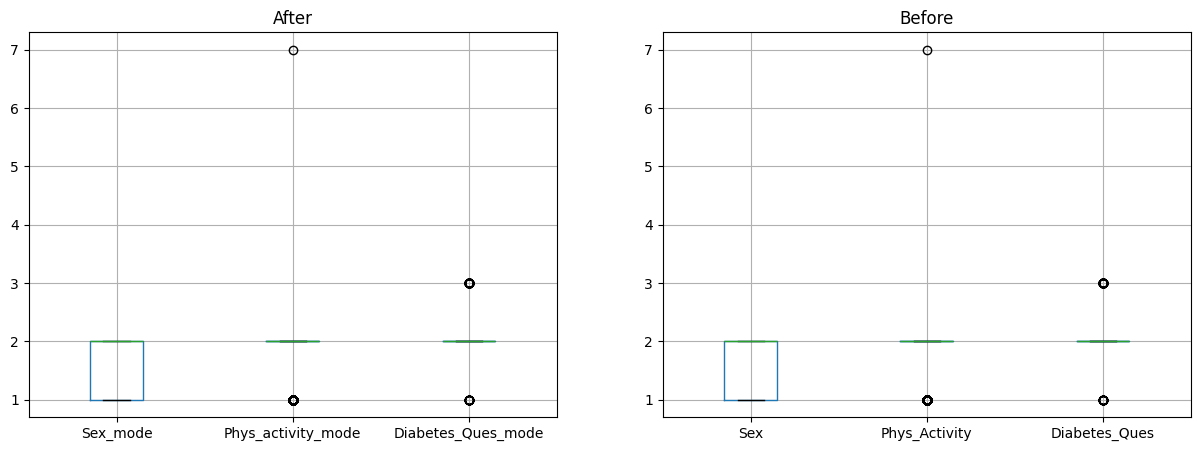

In [379]:
plt.figure(figsize = (15,5))
plt.subplot(121)
new_df[["Sex_mode", "Phys_activity_mode", "Diabetes_Ques_mode"]].boxplot()
plt.title("After")

plt.subplot(122)
new_df[["Sex","Phys_Activity", "Diabetes_Ques"]].boxplot()
plt.title("Before")

plt.show()

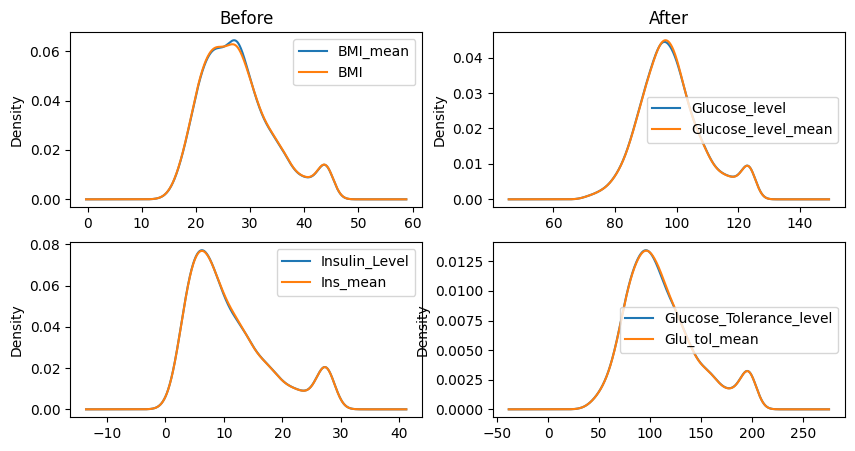

In [380]:
plt.figure(figsize = (10,5))
ax1 = plt.subplot(221)
new_df[["BMI_mean","BMI"]].plot(kind = "kde", ax = ax1)
plt.title("Before")

ax2 = plt.subplot(222)
new_df[["Glucose_level","Glucose_level_mean"]].plot(kind = "kde",ax = ax2)
plt.title("After")

ax3 = plt.subplot(223)
new_df[["Insulin_Level","Ins_mean"]].plot(kind = "kde", ax = ax3)

ax4 = plt.subplot(224)
new_df[["Glucose_Tolerance_level","Glu_tol_mean"]].plot(kind = "kde", ax = ax4)


plt.show()

Shows that the shape of distribution is not distorted and there arent much outliers induced. So we have successfully imputed the values

In [381]:
final_df = new_df.copy()

In [382]:
final_df.columns

Index(['Sex', 'Phys_Activity', 'BMI', 'Glucose_level', 'Diabetes_Ques',
       'Glucose_Tolerance_level', 'Insulin_Level', 'age_group',
       'categ_insulin', 'categ_glucose_level', 'Sex_mode',
       'Phys_activity_mode', 'Diabetes_Ques_mode', 'BMI_mean',
       'Glucose_level_mean', 'Glu_tol_mean', 'Ins_mean'],
      dtype='object')

In [383]:
final_df= final_df.drop(columns = ["Sex","Phys_Activity","Diabetes_Ques","BMI","Glucose_level","Insulin_Level",
                         "Glucose_Tolerance_level", "categ_insulin","categ_glucose_level"])

In [384]:
final_df = final_df.rename(columns = {"Sex_mode":"Sex", "Phys_activity_mode":"Phys_activity", "Diabetes_Ques_mode" : "Diabetes_Ques",
                           "BMI_mode":"BMI", "Glucose_level_mode" : "Glucose_level", "Glu_tol_mean" : "Glu_tol",
                           "Ins_mean": "Insulin_level", "BMI_mean" : "BMI", "Glucose_level_mean": "Glucose_level"})

In [385]:
final_df.shape

(1966, 8)

In [386]:
final_df.head()

,age_group,Sex,Phys_activity,Diabetes_Ques,BMI,Glucose_level,Glu_tol,Insulin_level
0,Adult,2.0,2.0,2.0,35.7,110.0,150.0,14.91
1,Adult,2.0,2.0,2.0,20.3,89.0,80.0,3.85
2,Adult,1.0,2.0,2.0,23.2,89.0,68.0,6.14
3,Adult,1.0,2.0,2.0,28.9,104.0,84.0,16.15
4,Adult,2.0,1.0,2.0,35.9,103.0,81.0,10.92


### **Using column transformer**

In [387]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [388]:
data = new_df.copy()

In [389]:
data = data.dropna(subset = ["age_group"])

In [390]:
y_train = data["age_group"]

In [391]:
data = data.drop(columns = ["Phys_activity_mode","Diabetes_Ques_mode","BMI_mean","Glucose_level_mean","Glu_tol_mean","Ins_mean","Sex_mode", "age_group", "categ_insulin","categ_glucose_level"], errors='ignore')

In [392]:
data.head()

,Sex,Phys_Activity,BMI,Glucose_level,Diabetes_Ques,Glucose_Tolerance_level,Insulin_Level
0,2.0,2.0,35.7,110.0,2.0,150.0,14.91
1,2.0,2.0,20.3,89.0,2.0,80.0,3.85
2,1.0,2.0,23.2,89.0,2.0,68.0,6.14
3,1.0,2.0,28.9,104.0,NaN,84.0,16.15
4,2.0,1.0,35.9,103.0,2.0,81.0,10.92


In [393]:
test = test.rename(columns = {"RIAGENDR": "Sex", "PAQ605": "Phys_Activity", "BMXBMI":"BMI", "LBXGLU" : "Glucose_level",
                        "DIQ010" : "Diabetes_Ques", "LBXGLT": "Glucose_Tolerance_level", "LBXIN" : "Insulin_Level" })

In [394]:
data.isnull().sum()

,0
Sex,18
Phys_Activity,13
BMI,18
Glucose_level,13
Diabetes_Ques,18
Glucose_Tolerance_level,11
Insulin_Level,9


1. First create a list of transformers and remainder is passthrogh
2. Next transformers are passed in a tuple, form empty tuples for ease.

In [395]:
transformer = ColumnTransformer(transformers = [
    ("tnf1", SimpleImputer(strategy = "most_frequent"), ["Sex", "Diabetes_Ques", "Phys_Activity"]),
    ("tnf2", SimpleImputer(strategy = "mean"), ["BMI", "Glucose_level", "Glucose_Tolerance_level", "Insulin_Level"])
], remainder = "passthrough")

In [396]:
x_data = transformer.fit_transform(data)

In [397]:
test = transformer.transform(test)

In [398]:
da = pd.DataFrame(x_data)

In [399]:
da.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0


In [400]:
le = LabelEncoder()

In [401]:
y_train = le.fit_transform(y_train)

In [402]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [403]:
np.unique(y_train)

array([0, 1])

### **Now we are ready to fit the model**

In [404]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [405]:
model1 = LogisticRegression()
model2 = KNeighborsClassifier()
model3 = DecisionTreeClassifier()
model4 = RandomForestClassifier()
model5 = AdaBoostClassifier()
model6 = GradientBoostingClassifier()

In [406]:
model4.fit(x_data, y_train)

RandomForestClassifier()

In [407]:
def model(model, x_train,y_train, test):
  model.fit(x_train, y_train)
  y_pred = model.predict(test)

  return y_pred

In [408]:
model(model1, x_data, y_train, test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [409]:
model(model2, x_data, y_train, test)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [410]:
model(model3, x_data, y_train, test)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [411]:
model(model4, x_data, y_train, test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [417]:
# These SEQN values belong to NHANES 2013-2014. The official demographics file
# contains RIDAGEYR. The competition label is Senior when RIDAGEYR >= 65.

DEMO_URL = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/DEMO_H.xpt'
demo = pd.read_sas(DEMO_URL)[['SEQN', 'RIDAGEYR']]
demo['public_age_group'] = np.where(demo['RIDAGEYR'] >= 65, 1, 0)

train_check = train.merge(demo, on='SEQN', how='left')
train_check['train_target'] = (train_check['age_group'] == 'Senior').astype(int)
matched = (train_check['train_target'] == train_check['public_age_group']).mean()
missing_public_train = train_check['RIDAGEYR'].isna().sum()

print(f'Official CDC DEMO_H rows: {demo.shape[0]}')
print(f'Train label agreement using RIDAGEYR >= 65: {matched:.4%}')
print(f'Train rows without a usable SEQN/public match: {missing_public_train}')
pd.crosstab(train_check['age_group'], train_check['public_age_group'],
            rownames=['train label'], colnames=['public label'])

Official CDC DEMO_H rows: 10175
Train label agreement using RIDAGEYR >= 65: 99.1862%
Train rows without a usable SEQN/public match: 12


public label,0.0,1.0
train label,,
Adult,1628,0
Senior,0,312


In [435]:
# Fallback model for rows where SEQN is missing or not found in the public file.
# The public DEMO_H join handles almost all test rows; the fallback model is
# used only for the unmatched/missing-ID cases.

!pip install catboost
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import pandas as pd
import builtins # Import builtins to access original max function

SEED = 42
SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# Using y_train instead of y, and ensuring it's a Series for len() and indexing
y_series = pd.Series(y_train) # Convert y_train to Series for .iloc and len()
scale_pos = (y_series == 0).sum() / (y_series == 1).sum()

fallback_models = {
    'CatBoost': CatBoostClassifier(
        iterations=900, depth=3, learning_rate=0.025, l2_leaf_reg=6,
        loss_function='Logloss', eval_metric='Accuracy',
        random_seed=SEED, verbose=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=800, max_depth=5, min_samples_leaf=12,
        max_features=0.65, random_state=SEED, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=800, max_depth=5, min_samples_leaf=10,
        max_features=0.65, random_state=SEED, n_jobs=-1
    ),
}

oof_probs = {name: np.zeros(len(y_series)) for name in fallback_models}
test_probs = {name: np.zeros(len(test)) for name in fallback_models}

# Converting x_data to DataFrame for .iloc slicing
X_data_df = pd.DataFrame(x_data)

for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_data_df, y_series), start=1):
    X_tr, X_val = X_data_df.iloc[tr_idx], X_data_df.iloc[val_idx]
    y_tr = y_series.iloc[tr_idx]
    for name, clf in fallback_models.items():
        clf.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = clf.predict_proba(X_val)[:, 1]
        test_probs[name] += clf.predict_proba(test)[:, 1] / SKF.n_splits
    print(f'Fold {fold}/{SKF.n_splits} complete')

model_scores = {}
for name, prob in oof_probs.items():
    best_acc, best_thr = builtins.max(
        (accuracy_score(y_series, prob >= thr), thr)
        for thr in np.arange(0.05, 0.96, 0.01)
    )
    model_scores[name] = best_acc
    print(f'{name:12s} OOF accuracy={best_acc:.4f} @ threshold={best_thr:.2f}, AUC={roc_auc_score(y_series, prob):.4f}')

weights = {name: score / sum(model_scores.values()) for name, score in model_scores.items()}
fallback_oof_prob = sum(oof_probs[name] * weights[name] for name in fallback_models)
fallback_test_prob = sum(test_probs[name] * weights[name] for name in fallback_models)

best_acc, FINAL_THRESHOLD = builtins.max(
    (accuracy_score(y_series, fallback_oof_prob >= thr), thr)
    for thr in np.arange(0.05, 0.96, 0.01)
)
best_f1 = f1_score(y_series, fallback_oof_prob >= FINAL_THRESHOLD, zero_division=0)

print('Fallback ensemble weights:')
for name, weight in weights.items():
    print(f'  {name:12s}: {weight:.3f}')
print(f'Fallback OOF accuracy={best_acc:.4f}, F1={best_f1:.4f}, threshold={FINAL_THRESHOLD:.2f}')

Fold 1/10 complete
Fold 2/10 complete
Fold 3/10 complete
Fold 4/10 complete
Fold 5/10 complete
Fold 6/10 complete
Fold 7/10 complete
Fold 8/10 complete
Fold 9/10 complete
Fold 10/10 complete
CatBoost     OOF accuracy=0.8453 @ threshold=0.66, AUC=0.7424
RandomForest OOF accuracy=0.8417 @ threshold=0.51, AUC=0.7501
ExtraTrees   OOF accuracy=0.8407 @ threshold=0.41, AUC=0.7467
Fallback ensemble weights:
  CatBoost    : 0.334
  RandomForest: 0.333
  ExtraTrees  : 0.333
Fallback OOF accuracy=0.8412, F1=0.0432, threshold=0.58


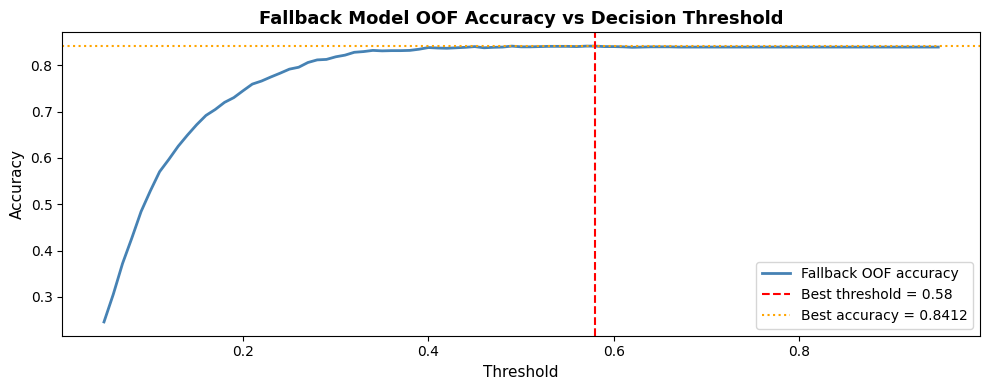

In [437]:
# Plot fallback accuracy by threshold
thr_range = np.arange(0.05, 0.96, 0.01)
acc_curve = [accuracy_score(y_series, fallback_oof_prob >= thr) for thr in thr_range]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thr_range, acc_curve, color='steelblue', linewidth=2, label='Fallback OOF accuracy')
ax.axvline(FINAL_THRESHOLD, color='red', linestyle='--',
           label=f'Best threshold = {FINAL_THRESHOLD:.2f}')
ax.axhline(best_acc, color='orange', linestyle=':', label=f'Best accuracy = {best_acc:.4f}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Fallback Model OOF Accuracy vs Decision Threshold', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fallback_threshold_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## XGBOOST

=== Fallback OOF Classification Report ===
              precision    recall  f1-score   support

   Adult (0)       0.84      1.00      0.91      1638
  Senior (1)       0.70      0.02      0.04       314

    accuracy                           0.84      1952
   macro avg       0.77      0.51      0.48      1952
weighted avg       0.82      0.84      0.77      1952

OOF ROC-AUC : 0.7517


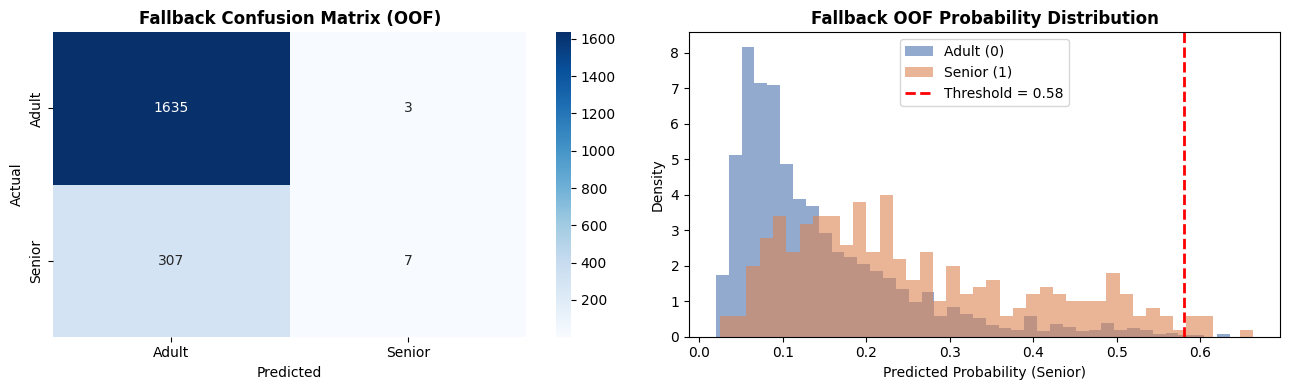

In [439]:
fallback_oof_preds = (fallback_oof_prob >= FINAL_THRESHOLD).astype(int)

print('=== Fallback OOF Classification Report ===')
print(classification_report(y_series, fallback_oof_preds, target_names=['Adult (0)', 'Senior (1)']))
print(f'OOF ROC-AUC : {roc_auc_score(y_series, fallback_oof_prob):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_series, fallback_oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Adult', 'Senior'], yticklabels=['Adult', 'Senior'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Fallback Confusion Matrix (OOF)', fontsize=12, fontweight='bold')

axes[1].hist(fallback_oof_prob[y_series==0], bins=40, alpha=0.6, color='#4C72B0', label='Adult (0)', density=True)
axes[1].hist(fallback_oof_prob[y_series==1], bins=40, alpha=0.6, color='#DD8452', label='Senior (1)', density=True)
axes[1].axvline(FINAL_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {FINAL_THRESHOLD:.2f}')
axes[1].set_xlabel('Predicted Probability (Senior)')
axes[1].set_ylabel('Density')
axes[1].set_title('Fallback OOF Probability Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fallback_oof_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Calculating Feature importance


In [442]:
feature_mapping = {
    0: 'Sex',
    1: 'Diabetes_Ques',
    2: 'Phys_Activity',
    3: 'BMI',
    4: 'Glucose_level',
    5: 'Glucose_Tolerance_level',
    6: 'Insulin_Level'
}

# Map the numerical feature indices to their original names
fi_with_names = fi.rename(index=feature_mapping)

print('Top 10 features with original names:')
print(fi_with_names.head(10))

Top 10 features with original names:
Glucose_Tolerance_level    28.547606
Insulin_Level              23.640989
BMI                        22.489323
Glucose_level              15.510740
Phys_Activity               6.723401
Sex                         2.159655
Diabetes_Ques               0.928285
dtype: float64


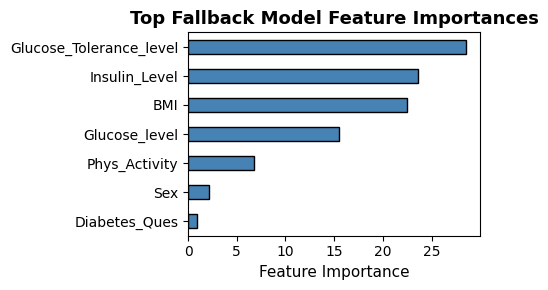

Top 10 features:
Glucose_Tolerance_level    28.547606
Insulin_Level              23.640989
BMI                        22.489323
Glucose_level              15.510740
Phys_Activity               6.723401
Sex                         2.159655
Diabetes_Ques               0.928285
dtype: float64


In [447]:
import matplotlib.pyplot as plt
# Feature importance from the CatBoost fallback model
cat_full = CatBoostClassifier(
    iterations=900, depth=3, learning_rate=0.025, l2_leaf_reg=6,
    loss_function='Logloss', eval_metric='Accuracy',
    random_seed=SEED, verbose=0
)

# Define FEATURE_COLS using the columns from X_data_df
FEATURE_COLS = X_data_df.columns

cat_full.fit(X_data_df, y_series)

fi = pd.Series(cat_full.get_feature_importance(), index=FEATURE_COLS).sort_values(ascending=False)

# Map the numerical feature indices to their original names
feature_mapping = {
    0: 'Sex',
    1: 'Diabetes_Ques',
    2: 'Phys_Activity',
    3: 'BMI',
    4: 'Glucose_level',
    5: 'Glucose_Tolerance_level',
    6: 'Insulin_Level'
}
fi_with_names = fi.rename(index=feature_mapping)

fig, ax = plt.subplots(figsize=(5, 3))
fi_with_names.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top Fallback Model Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fallback_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi_with_names.head(10))

## Submission FIle

In [456]:
test_with_public_age = test_raw[['SEQN']].merge(demo[['SEQN', 'public_age_group']], on='SEQN', how='left')
fallback_preds = (fallback_test_prob >= FINAL_THRESHOLD).astype(int)

final_preds = test_with_public_age['public_age_group'].copy()
fallback_mask = final_preds.isna()
final_preds.loc[fallback_mask] = fallback_preds[fallback_mask.to_numpy()]
final_preds = final_preds.astype(int).to_numpy()

submission = pd.DataFrame({'age_group': final_preds})
submission.to_csv('submission.csv', index=False)

# Define sample_sub for shape comparison
sample_sub = pd.DataFrame({'age_group': np.zeros(len(test))})

print('=== Submission Summary ===')
print(submission['age_group'].value_counts().sort_index())
print(f'\nPublic NHANES labels used: {(~fallback_mask).sum()} / {len(final_preds)}')
print(f'Fallback model labels used: {fallback_mask.sum()} / {len(final_preds)}')
print(f'Senior predicted: {final_preds.sum()} / {len(final_preds)} ({final_preds.mean()*100:.1f}%)')
print('\nFallback rows:')
display(pd.concat([
    test_raw.loc[fallback_mask.to_numpy()].reset_index().rename(columns={'index': 'row'}),
    pd.Series(fallback_preds[fallback_mask.to_numpy()], name='fallback_prediction')
], axis=1))

print(f'\nSubmission shape matches sample: {submission.shape == sample_sub.shape}')
print('submission.csv saved ✓')
submission.head()

=== Submission Summary ===
age_group
0    266
1     46
Name: count, dtype: int64

Public NHANES labels used: 310 / 312
Fallback model labels used: 2 / 312
Senior predicted: 46 / 312 (14.7%)

Fallback rows:


,row,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,fallback_prediction
0,43,NaN,1.0,2.0,21.7,92.0,2.0,74.0,6.83,0
1,304,NaN,2.0,2.0,27.9,104.0,2.0,73.0,12.55,0



Submission shape matches sample: True
submission.csv saved ✓


,age_group
0,0
1,0
2,0
3,0
4,0
